# Bottleneck-Analyse im Karosseriebau
## Arbeitsnotebook — Zweierteams

Dieses Notebook begleitet euch durch die Analyse. Es ist kein fertiges Skript zum Durchklicken — jede Sektion enthält Code, den ihr verstehen, anpassen und auf eure eigene Fragestellung übertragen sollt.

**Wie ihr damit arbeitet:**
- Lest die Markdown-Zellen vor dem Code. Dort stehen die Fragen, über die ihr nachdenken sollt.
- Führt den Code erst auf dem **Beispieldatensatz** aus. Erst wenn er dort funktioniert, wechselt ihr auf die echten Daten.
- Haltet eure eigenen Beobachtungen und Entscheidungen in Markdown-Zellen fest — das ist gleichzeitig eure Dokumentation.

---


## 0 · Setup

Alle Imports an einem Ort. Wenn hier etwas fehlt, installiert es mit `pip install paketname`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

print('Setup fertig.')


Setup fertig.


---
## 1 · Beispieldatensatz aufbauen

### Warum zuerst ein Beispieldatensatz?

Die echten Produktionsdaten des Konzerns sind vertraulich — sie dürfen nicht auf GitHub, nicht in ChatGPT, nicht per E-Mail weitergegeben werden. Der Beispieldatensatz hat dieselbe **Struktur** wie die echten Daten, aber bewusst andere Größenordnungen und vereinfachte Namen. So könnt ihr:

- Eure Analysemethoden entwickeln und testen, ohne Unternehmensgeheimnisse weiterzugeben
- KI-Tools für Code-Fragen nutzen (mit dem Beispieldatensatz, nicht den echten Daten)
- Den Code auf GitHub stellen

**Bevor ihr den Beispieldatensatz generiert, analysiert zuerst die echten Daten lokal:**

```python
df_echt = pd.read_csv('data/produktionsdaten.csv')
print(df_echt.dtypes)
print(df_echt.nunique())
print(df_echt.groupby('station')['roboter_id'].nunique().sort_values())
print(df_echt['typ'].value_counts(normalize=True).round(2))
```

Beantwortet dabei:
- Wie viele Stationen gibt es? Welche haben keine Roboter?
- Wie viele Roboter hat eine typische Station, wie viele die roboterreichste?
- Welche Karosserietypen gibt es, wie sind sie verteilt?
- Gibt es eine Fehler- oder Statusspalte?

Dann passt die Konstanten unten entsprechend an — mit **anderen Zahlenwerten** als in den echten Daten.


In [2]:
np.random.seed(42)

# ---------------------------------------------------------------------------
# HIER ANPASSEN: Struktur aus den echten Daten ableiten, Werte verfremden
# ---------------------------------------------------------------------------
STATIONEN = {
    # station_id : (n_roboter, basis_taktzeit_sek)
    'S01': (0, 18),   # keine Roboter (Uebergang / manuell)
    'S02': (2, 22),
    'S03': (3, 19),
    'S04': (4, 31),   # <- absichtlich hoehere Basis (eingebauter Engpass)
    'S05': (3, 20),
    'S06': (0, 14),   # keine Roboter
    'S07': (5, 25),
    'S08': (3, 21),
    'S09': (2, 23),
    'S10': (1, 16),
}

TYPEN = {'Typ_A': 1.00, 'Typ_B': 1.20, 'Typ_C': 0.90}
FEHLERRATE = 0.025   # 2.5% der Robotereinsaetze haben Fehler
N = 200              # Anzahl Karosserien
# ---------------------------------------------------------------------------

records = []
for i in range(N):
    typ = np.random.choice(list(TYPEN), p=[0.45, 0.35, 0.20])
    typ_faktor = TYPEN[typ]

    for station, (n_rob, basis) in STATIONEN.items():
        if n_rob == 0:
            stationszeit = max(2.0, np.random.normal(basis * typ_faktor, basis * 0.07))
            records.append({
                'karosserie_id': f'K{i:04d}',
                'typ':           typ,
                'station':       station,
                'roboter_id':    None,
                'taktzeit_sek':  round(stationszeit, 1),
                'fehler':        False,
            })
        else:
            for r in range(1, n_rob + 1):
                rob_id = f'{station}_R{r:02d}'
                basis_rob = (basis * typ_faktor) / n_rob
                if rob_id == 'S04_R02':   # eingebauter Ausreisser
                    basis_rob *= 1.40
                taktzeit = max(1.0, np.random.normal(basis_rob, basis_rob * 0.09))
                fehler   = np.random.random() < FEHLERRATE
                records.append({
                    'karosserie_id': f'K{i:04d}',
                    'typ':           typ,
                    'station':       station,
                    'roboter_id':    rob_id,
                    'taktzeit_sek':  round(taktzeit, 1),
                    'fehler':        fehler,
                })

df = pd.DataFrame(records)

df_station = (
    df.groupby(['karosserie_id', 'typ', 'station'], as_index=False)
    .agg(stationszeit_sek=('taktzeit_sek', 'sum'),
         fehler_in_station=('fehler', 'any'))
)

import os; os.makedirs('data', exist_ok=True); os.makedirs('plots', exist_ok=True)
df.to_csv('data/beispiel_roboter.csv', index=False)
df_station.to_csv('data/beispiel_stationen.csv', index=False)

print(df.head(8))
print(f'\n{len(df):,} Eintraege | {df_station["karosserie_id"].nunique()} Karosserien')
print(f'Fehlerrate: {df["fehler"].mean()*100:.1f}%')


  karosserie_id    typ station roboter_id  taktzeit_sek  fehler
0         K0000  Typ_A     S01       None          16.6   False
1         K0000  Typ_A     S02    S02_R01          11.3   False
2         K0000  Typ_A     S02    S02_R02          12.6    True
3         K0000  Typ_A     S03    S03_R01           6.8   False
4         K0000  Typ_A     S03    S03_R02           6.1   False
5         K0000  Typ_A     S03    S03_R03           6.6   False
6         K0000  Typ_A     S04    S04_R01           7.9   False
7         K0000  Typ_A     S04    S04_R02           9.0   False

5,000 Eintraege | 200 Karosserien
Fehlerrate: 2.4%


**Schnell-Check:** Sieht der Datensatz so aus wie erwartet?
- Haben die richtigen Stationen `None` als `roboter_id`?
- Stimmen die Größenordnungen der Taktzeiten?
- Ist die Fehlerrate ungefähr bei eurem Zielwert?

Wenn nicht — debuggt hier, bevor ihr weitermacht.


---
## 2 · Erste Exploration

Bevor ihr eine spezifische Frage beantwortet: schaut euch die Daten an. Was fällt auf? Was überrascht euch?

> **Haltet eure Beobachtungen in einer Markdown-Zelle fest** — das ist der Startpunkt für eure Fragestellung.


In [3]:
print('=== Stationszeit-Uebersicht ===')
print(df_station.groupby('station')['stationszeit_sek']
      .agg(['mean', 'median', 'std', 'min', 'max'])
      .round(1)
      .sort_values('median', ascending=False))

print('\n=== Karosserietypen ===')
print(df_station['typ'].value_counts())

print('\n=== Fehlerrate je Station ===')
print(df_station.groupby('station')['fehler_in_station']
      .mean().round(3).sort_values(ascending=False))


=== Stationszeit-Uebersicht ===
         mean  median  std   min   max
station                               
S04      35.9    34.9  4.2  28.3  44.9
S07      26.3    25.4  3.2  20.7  32.7
S09      24.3    23.8  3.1  18.8  32.4
S02      23.2    23.0  2.8  17.6  29.7
S08      21.9    21.4  2.6  16.8  27.8
S05      21.0    20.4  2.6  15.9  26.8
S03      19.9    19.3  2.4  14.8  25.6
S01      18.8    18.4  2.5  13.4  25.0
S10      16.8    16.7  2.4  11.0  22.4
S06      14.6    14.3  2.0  10.8  18.8

=== Karosserietypen ===
typ
Typ_A    950
Typ_B    680
Typ_C    370
Name: count, dtype: int64

=== Fehlerrate je Station ===
station
S04    0.150
S03    0.135
S07    0.090
S02    0.070
S08    0.060
S05    0.045
S10    0.025
S09    0.020
S01    0.000
S06    0.000
Name: fehler_in_station, dtype: float64


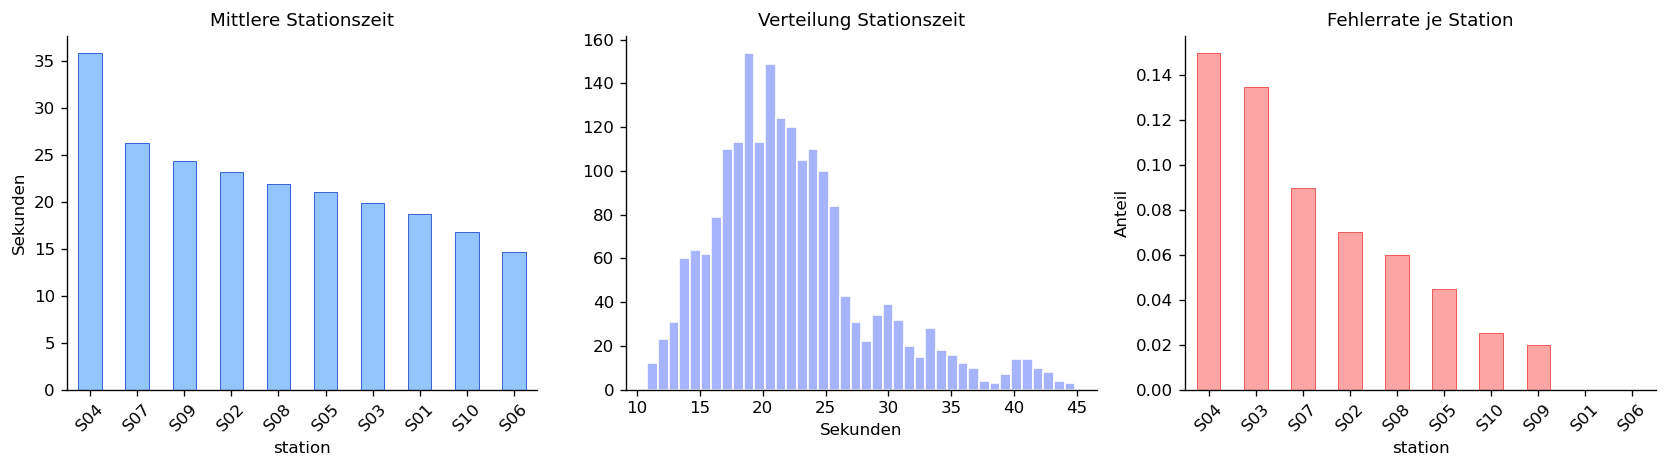

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

(df_station.groupby('station')['stationszeit_sek']
 .mean().sort_values(ascending=False)
 .plot(kind='bar', ax=axes[0], color='#93C5FD', edgecolor='#1D4ED8', linewidth=0.5))
axes[0].set_title('Mittlere Stationszeit')
axes[0].set_ylabel('Sekunden')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(df_station['stationszeit_sek'], bins=40, color='#A5B4FC', edgecolor='white')
axes[1].set_title('Verteilung Stationszeit')
axes[1].set_xlabel('Sekunden')

(df_station.groupby('station')['fehler_in_station']
 .mean().sort_values(ascending=False)
 .plot(kind='bar', ax=axes[2], color='#FCA5A5', edgecolor='#EF4444', linewidth=0.5))
axes[2].set_title('Fehlerrate je Station')
axes[2].set_ylabel('Anteil')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/00_exploration.png', dpi=150, bbox_inches='tight')
plt.show()


> **Eure Beobachtungen hier eintragen:**
>
> - Was fällt auf?
> - Welche Station oder welcher Typ zieht die Aufmerksamkeit auf sich?
> - Was wollt ihr genauer untersuchen?

*(Diese Zelle durch eure eigenen Notizen ersetzen.)*


---
## 3 · Fragestellung 1 — Wo liegt der Taktzeit-Engpass?

Der langsamste Schritt bestimmt den Durchsatz der gesamten Linie. Nicht nur der Mittelwert zählt — Streuung und Extremwerte auch.

**Überlegt euch vor dem Code:**
- Was ist der Unterschied zwischen Mittelwert, Median und 95. Perzentil? Wann ist welche Kennzahl für den Konzern relevanter?
- Was bedeutet es, wenn eine Station einen niedrigen Median, aber ein hohes P95 hat?
- Wie würdet ihr einem Produktionsleiter erklären, warum ihr den Median statt des Mittelwerts zeigt?


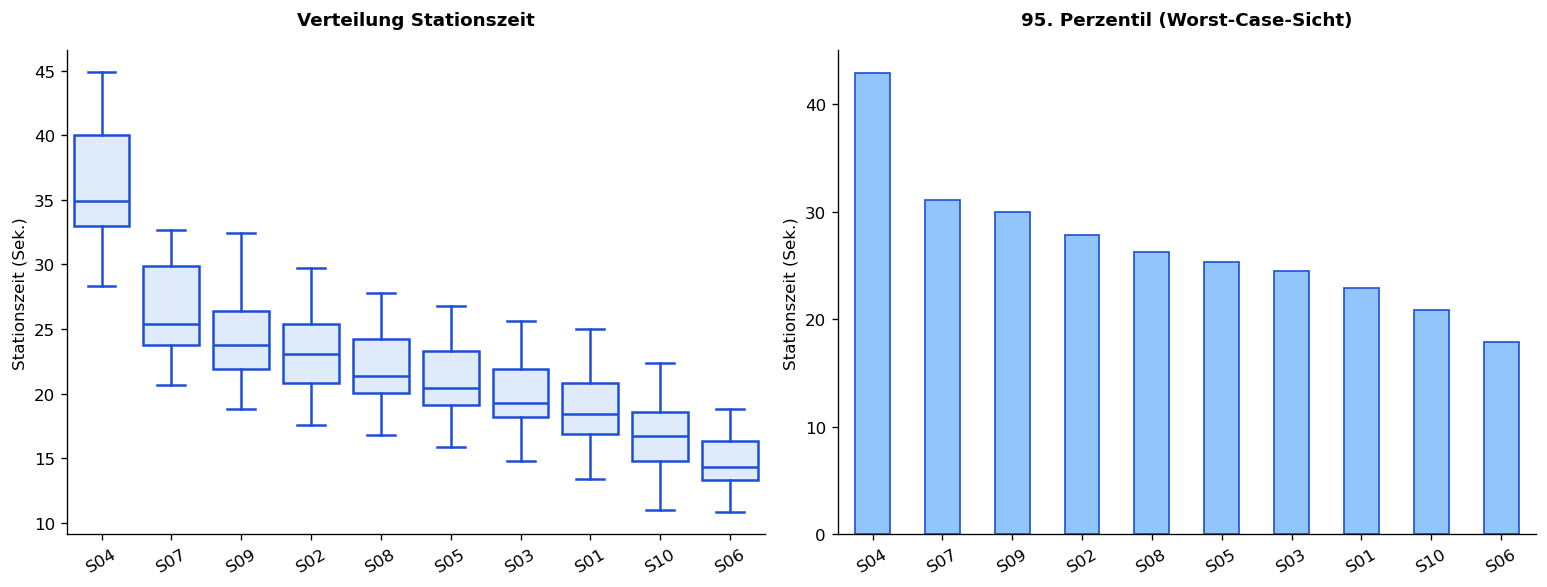

         Median  Mittelwert   P95  Std
station                               
S04        34.9        35.9  42.9  4.2
S07        25.4        26.3  31.1  3.2
S09        23.8        24.3  30.0  3.1
S02        23.0        23.2  27.8  2.8
S08        21.4        21.9  26.3  2.6
S05        20.4        21.0  25.3  2.6
S03        19.3        19.9  24.5  2.4
S01        18.4        18.8  22.9  2.5
S10        16.7        16.8  20.9  2.4
S06        14.3        14.6  17.9  2.0


In [17]:
# 1. Datenvorbereitung: Ranking berechnen
stats = (df_station
    .groupby('station')['stationszeit_sek']
    .agg(Median='median', Mittelwert='mean', 
         P95=lambda x: x.quantile(0.95), Std='std')
    .round(1)
    .sort_values('Median', ascending=False)
)
stationen_order = stats.index.tolist()

# 2. Plotting Setup
fig, axes = plt.subplots(1, 2, figsize=(13, 5)) # Höhe leicht erhöht für Label-Platz

# --- Linker Plot: Boxplot (Verteilung) ---
sns.boxplot(
    data=df_station, 
    x='station', 
    y='stationszeit_sek', 
    order=stationen_order,
    ax=axes[0],
    color='#DBEAFE',          # Füllt die Boxen (Hintergrund)
    # Entferne 'linecolor', stattdessen:
    boxprops=dict(edgecolor='#1D4ED8'), # Linienfarbe der Box
    medianprops=dict(color='#1D4ED8'),  # Linienfarbe des Medians
    whiskerprops=dict(color='#1D4ED8'), # Linienfarbe der Antennen
    capprops=dict(color='#1D4ED8'),     # Linienfarbe der Endkappen
    flierprops=dict(marker='o', markersize=3, alpha=0.4, markeredgecolor='#1D4ED8')
)
axes[0].set_title('Verteilung Stationszeit', fontweight='bold', pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Stationszeit (Sek.)')
axes[0].tick_params(axis='x', rotation=30)

# --- Rechter Plot: Barplot (P95) ---
stats['P95'].reindex(stationen_order).plot(
    kind='bar', 
    ax=axes[1], 
    color='#93C5FD', 
    edgecolor='#1D4ED8', 
    linewidth=1
)
axes[1].set_title('95. Perzentil (Worst-Case-Sicht)', fontweight='bold', pad=15)
axes[1].set_ylabel('Stationszeit (Sek.)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# 3. Layout-Finish
sns.despine() # Entfernt die oberen/rechten Rahmen für einen moderneren Look
plt.tight_layout()

# Speichern & Zeigen
import os
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/frage1_engpass.png', dpi=150, bbox_inches='tight')
plt.show()

print(stats)

**Was ihr hier seht:** Der Median zeigt den typischen Fall. Das 95. Perzentil zeigt, womit man in 1 von 20 Fällen rechnen muss. Eine Station mit niedrigem Median aber hohem P95 hat ein anderes Problem als eine durchgehend langsame Station — und braucht eine andere Lösung.

> **Für eure Fragestellung:** Welche Station würdet ihr dem Konzern als kritisch markieren — und warum genau diese? Schreibt die Kernaussage als einen Satz auf.


---
## 4 · Fragestellung 2 — Treiben bestimmte Karosserietypen die Taktzeit?

**Überlegt euch vor dem Code:**
- Was wäre die Implikation, wenn ein Typ an *allen* Stationen länger braucht?
- Was wäre die Implikation, wenn ein Typ nur an *einer einzelnen* Station auffällig ist?
- Wie viele Karosserien je Typ sind in euren Daten? Warum ist das relevant für die Interpretation?


In [ ]:
pivot = (
    df_station.groupby(['station', 'typ'])['stationszeit_sek']
    .mean().round(1).unstack('typ')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=axes[0],
            cbar_kws={'label': 'Stationszeit (Sek.)'})
axes[0].set_title('Mittlere Stationszeit: Typ x Station')
axes[0].set_ylabel('')

baseline = pivot.iloc[:, 0]   # erste Spalte als Referenz
rel = ((pivot.div(baseline, axis=0) - 1) * 100).round(1)
sns.heatmap(rel, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=0, linewidths=0.4, ax=axes[1],
            cbar_kws={'label': f'Mehrzeit vs. {pivot.columns[0]} (%)'})
axes[1].set_title('Relative Mehrzeit vs. Referenztyp')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('plots/frage2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Stichprobengroesse je Typ:')
print(df_station['typ'].value_counts())


> **Für eure Fragestellung:** Gibt es eine Station, bei der der Typ-Effekt besonders stark ist? Was könnte das bedeuten — ist das ein Typ-Problem oder ein Stations-Problem?

> Wenn ihr diesen Plot auf Folie 1 zeigen würdet: Welche **eine** Zelle in der Heatmap würdet ihr hervorheben? Warum diese?


---
## 5 · Fragestellung 3 — Gibt es einen Ausreißer-Roboter?

Wenn ein einzelner Roboter systematisch langsamer ist, bestimmt er den Stationstakt — unabhängig davon, wie schnell die anderen sind.

**Überlegt euch vor dem Code:**
- Was ist der Unterschied zwischen einem Roboter, der *manchmal* sehr langsam ist (hohe Varianz) und einem, der *immer* etwas langsamer ist (hoher Mittelwert)?
- Ab wann ist ein Unterschied groß genug, dass er operativ relevant ist?
- Der Z-Score vergleicht jeden Roboter mit dem Durchschnitt *innerhalb der Station*. Warum ist das sinnvoller als ein stationsübergreifender Vergleich?


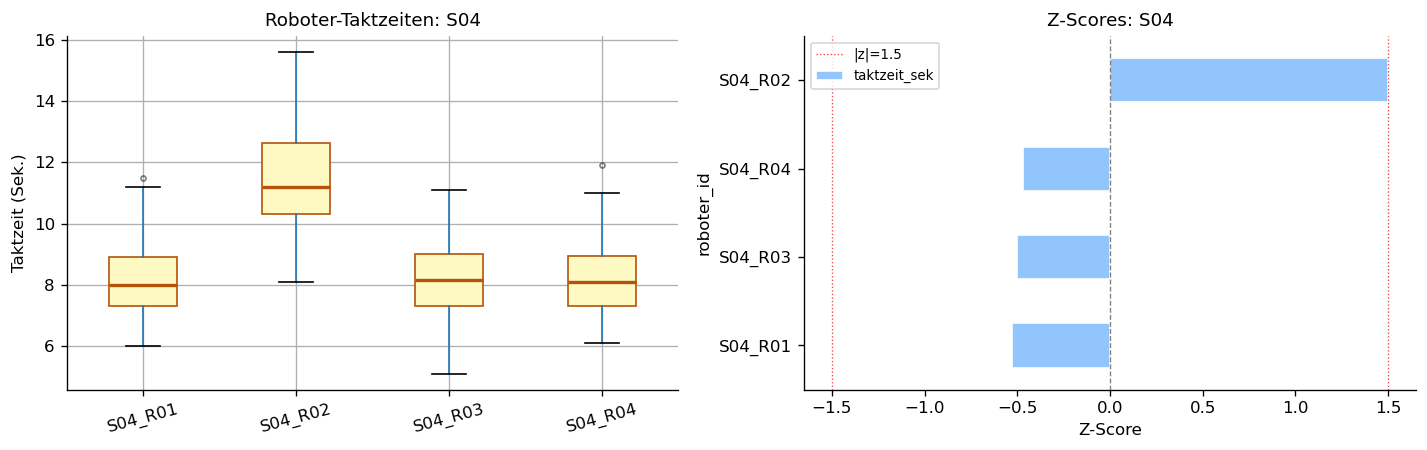

Kennzahlen je Roboter:
             mean   std  count
roboter_id                    
S04_R01      8.13  1.12    200
S04_R02     11.38  1.61    200
S04_R03      8.17  1.14    200
S04_R04      8.22  1.13    200

Z-Scores: {'S04_R01': -0.53, 'S04_R02': 1.5, 'S04_R03': -0.5, 'S04_R04': -0.47}


In [6]:
# Station waehlen: wo habt ihr in Frage 1 oder 2 etwas Auffaelliges gesehen?
station_focus = 'S04'   # <-- hier anpassen

df_rob_focus = df[(df['station'] == station_focus) & (df['roboter_id'].notna())].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_rob_focus.boxplot(
    column='taktzeit_sek', by='roboter_id', ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='#FEF9C3', color='#B45309'),
    medianprops=dict(color='#B45309', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5),
)
axes[0].set_title(f'Roboter-Taktzeiten: {station_focus}')
axes[0].set_xlabel('')
axes[0].set_ylabel('Taktzeit (Sek.)')
plt.sca(axes[0]); plt.xticks(rotation=15); plt.suptitle('')

mittel = df_rob_focus.groupby('roboter_id')['taktzeit_sek'].mean()
z = (mittel - mittel.mean()) / mittel.std()
colors = ['#EF4444' if abs(v) > 1.5 else '#93C5FD' for v in z.sort_values()]
z.sort_values().plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].axvline(1.5, color='#EF4444', linewidth=0.8, linestyle=':', label='|z|=1.5')
axes[1].axvline(-1.5, color='#EF4444', linewidth=0.8, linestyle=':')
axes[1].set_title(f'Z-Scores: {station_focus}')
axes[1].set_xlabel('Z-Score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'plots/frage3_roboter_{station_focus}.png', dpi=150, bbox_inches='tight')
plt.show()

print('Kennzahlen je Roboter:')
print(df_rob_focus.groupby('roboter_id')['taktzeit_sek']
      .agg(['mean', 'std', 'count']).round(2))
print('\nZ-Scores:', z.round(2).to_dict())


**Z-Score Faustregel:** |z| > 1.5 auffällig, |z| > 2.0 klares Signal.

> **Für eure Fragestellung:** Was wäre die Empfehlung an den Konzern, wenn ihr einen Ausreißer-Roboter findet? Was müsste man wissen, um von 'auffällig' zu 'wartungsbedürftig' zu kommen? Das ist eine gute Frage für Folie 2.


---
## 6 · Fragestellung 4 — Lineares Modell: Was erklärt die Stationszeit?

**Überlegt euch vor dem Code:**
- Was ist der Unterschied zwischen *Korrelation* und *Kausalität*? Warum ist das hier relevant?
- Was bedeutet es, einen Karosserietyp als Dummy-Variable ins Modell aufzunehmen? Welcher Typ ist die Referenzkategorie, und was sagt der Koeffizient eines anderen Typs aus?
- Wann ist ein R² 'gut genug'? Was bedeutet es, wenn das Modell 60% der Varianz erklärt — und was bedeuten die anderen 40%?


In [7]:
df_rob_agg = (
    df[df['roboter_id'].notna()]
    .groupby(['karosserie_id', 'station'])['taktzeit_sek']
    .agg(roboterzeit_max='max', roboterzeit_sum='sum')
    .reset_index()
)
df_model = df_station.merge(df_rob_agg, on=['karosserie_id', 'station'], how='left')

station_focus = 'S04'   # <-- anpassen
df_m = df_model[(df_model['station'] == station_focus)
                & df_model['roboterzeit_max'].notna()].copy()

model = smf.ols('stationszeit_sek ~ roboterzeit_max + C(typ)', data=df_m).fit()

coef_df = pd.DataFrame({
    'Koeffizient': model.params,
    'KI unten':    model.conf_int()[0],
    'KI oben':     model.conf_int()[1],
    'p-Wert':      model.pvalues,
}).round(3)
print(coef_df)
print(f'\nR2 = {model.rsquared:.3f}  -> Modell erklaert {model.rsquared*100:.1f}% der Varianz')
print(f'N  = {int(model.nobs)}')


                 Koeffizient  KI unten  KI oben  p-Wert
Intercept             23.622    21.644   25.599     0.0
C(typ)[T.Typ_B]        4.582     4.013    5.150     0.0
C(typ)[T.Typ_C]       -2.306    -2.837   -1.774     0.0
roboterzeit_max        0.980     0.799    1.160     0.0

R2 = 0.905  -> Modell erklaert 90.5% der Varianz
N  = 200


In [15]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       stationszeit_sek   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     623.2
Date:                Mon, 11 May 2026   Prob (F-statistic):          6.25e-100
Time:                        10:06:23   Log-Likelihood:                -333.52
No. Observations:                 200   AIC:                             675.0
Df Residuals:                     196   BIC:                             688.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          23.6217      1.003     

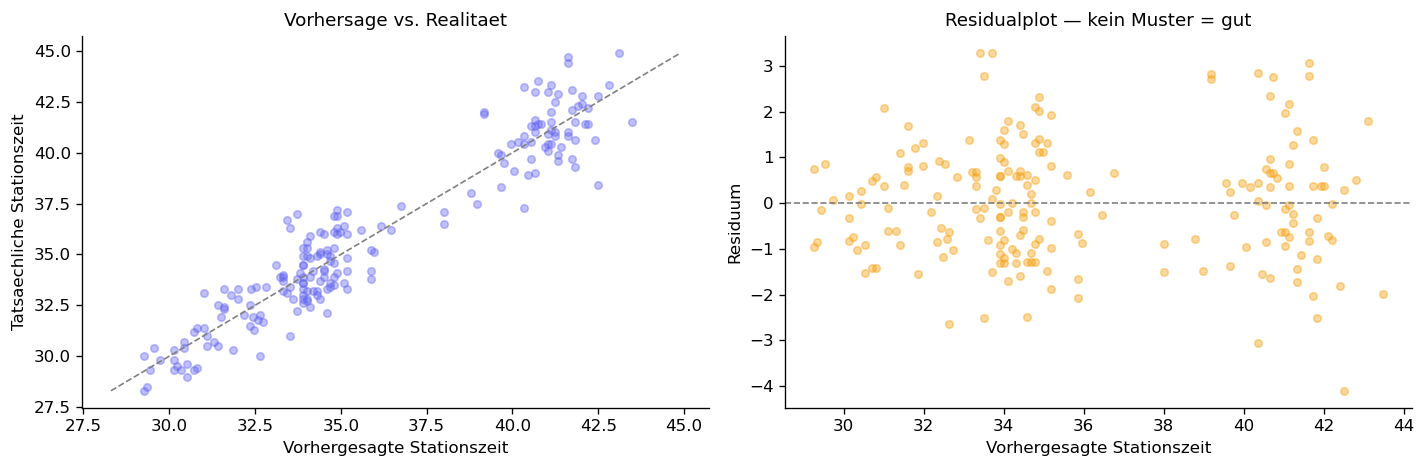

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pred = model.predict(df_m)
residuen = df_m['stationszeit_sek'] - pred

axes[0].scatter(pred, df_m['stationszeit_sek'], alpha=0.4, s=20, color='#6366F1')
lim = [min(pred.min(), df_m['stationszeit_sek'].min()),
       max(pred.max(), df_m['stationszeit_sek'].max())]
axes[0].plot(lim, lim, '--', color='gray', linewidth=1)
axes[0].set_xlabel('Vorhergesagte Stationszeit')
axes[0].set_ylabel('Tatsaechliche Stationszeit')
axes[0].set_title('Vorhersage vs. Realitaet')

axes[1].scatter(pred, residuen, alpha=0.4, s=20, color='#F59E0B')
axes[1].axhline(0, color='gray', linewidth=1, linestyle='--')
axes[1].set_xlabel('Vorhergesagte Stationszeit')
axes[1].set_ylabel('Residuum')
axes[1].set_title('Residualplot — kein Muster = gut')

plt.tight_layout()
plt.savefig(f'plots/frage4_modell_{station_focus}.png', dpi=150, bbox_inches='tight')
plt.show()


**Was ihr prüft:**
- *Vorhersage vs. Realität:* Punkte nah an der Diagonalen = gutes Modell.
- *Residualplot:* Kein Muster in den Residuen = Modellannahmen erfüllt. Trichterform (wachsende Streuung) = Problem.

> **Für eure Fragestellung:** Welcher Koeffizient ist am interessantesten für den Konzern? Formuliert die Aussage: *'Wenn X um 1 Einheit steigt, verändert sich die Stationszeit um Y Sekunden — alles andere gleichgehalten.'*


---
## 7 · Fragestellung 5 — Zeitliche Muster in der Produktionssequenz

Gibt es Einlaufeffekte, Schichtmuster oder Drift über den Produktionstag?

**Überlegt euch vor dem Code:**
- Was wäre ein möglicher physischer Grund für steigende Taktzeiten über die Schicht?
- Warum ist ein *gleitender Mittelwert* informativer als ein Scatterplot der Rohwerte?
- Was bedeutet eine Pearson-Korrelation von r = 0.05? Von r = 0.25? Ab wann würdet ihr das dem Konzern melden?

> **Voraussetzung:** Diese Analyse setzt voraus, dass die Daten in Produktionsreihenfolge vorliegen (oder einen Zeitstempel haben). Prüft das zuerst an den echten Daten.


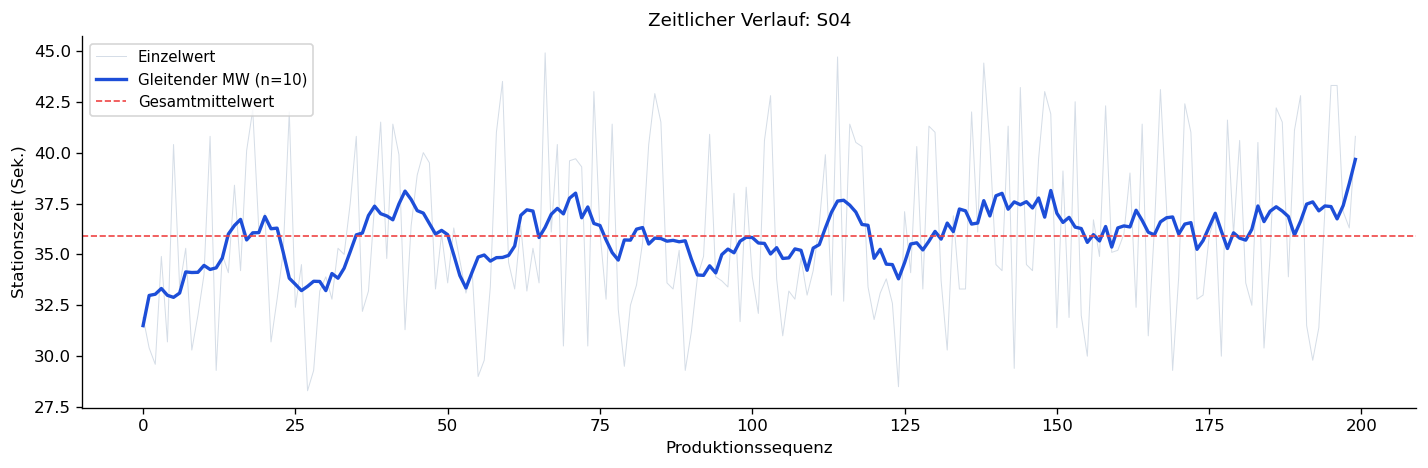

Pearson r = 0.166  (p = 0.019)
-> Schwacher Trend — beobachtenswert.


In [9]:
station_focus = 'S04'   # <-- anpassen

df_seq = (
    df_station[df_station['station'] == station_focus]
    .copy().reset_index(drop=True)
)
df_seq['seq'] = df_seq.index
fenster = max(10, len(df_seq) // 20)
df_seq['rolling_mean'] = df_seq['stationszeit_sek'].rolling(
    window=fenster, center=True, min_periods=fenster//2).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_seq['seq'], df_seq['stationszeit_sek'],
        color='#CBD5E1', linewidth=0.6, alpha=0.8, label='Einzelwert')
ax.plot(df_seq['seq'], df_seq['rolling_mean'],
        color='#1D4ED8', linewidth=2, label=f'Gleitender MW (n={fenster})')
ax.axhline(df_seq['stationszeit_sek'].mean(),
           color='#EF4444', linestyle='--', linewidth=1, label='Gesamtmittelwert')
ax.set_xlabel('Produktionssequenz')
ax.set_ylabel(f'Stationszeit (Sek.)')
ax.set_title(f'Zeitlicher Verlauf: {station_focus}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'plots/frage5_verlauf_{station_focus}.png', dpi=150, bbox_inches='tight')
plt.show()

r, p = scipy_stats.pearsonr(df_seq['seq'], df_seq['stationszeit_sek'])
print(f'Pearson r = {r:.3f}  (p = {p:.3f})')
if abs(r) < 0.1:
    print('-> Kein nennenswerter linearer Trend.')
elif abs(r) < 0.3:
    print('-> Schwacher Trend — beobachtenswert.')
else:
    print('-> Deutlicher Trend — melden!')


> **Für eure Fragestellung:** Ist ein Trend sichtbar — und bei welcher Station? Gilt er für alle Typen, oder nur für bestimmte?

> *(Tipp für Folie 2: 'Wir haben X gesehen. Um zu verstehen warum, müssten wir Y wissen.')*


---
## 8 · Eure eigene Fragestellung

Ihr habt jetzt Werkzeuge und Datensatz. Jetzt seid ihr dran.

Eine gute analytische Frage ist:
- **Beantwortbar:** Welche Spalten brauche ich genau? Habe ich sie?
- **Konkret:** Kann ich die Frage in einem Satz aufschreiben?
- **Relevant:** Was würde der Konzern anders machen, wenn er das Ergebnis kennt?

---

**Schreibt eure Frage hier auf:**

> *[Eure Frage in einem Satz]*

**Was erwartet ihr zu finden?**

> *[Hypothese: 1–2 Sätze]*

**Wie wollt ihr vorgehen?**

> *[Kurzer Analyseplan: Methode, welche Variablen, welche Visualisierung]*

---


In [10]:
# Euer eigener Code hier
